# **Exploratory Data Analysis – Mental Health & Burnout**

In this notebook we explore the dataset used for our burnout prediction model.

We will look at:
- the structure and quality of the data
- the variables used in the model
- how the variables are distributed
- relationships between the variables and `Burnout_Score`
- correlations between the model variables

The purpose of the EDA is to understand the data before training and evaluating the machine learning models.

## **Load the dataset**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

from sklearn.preprocessing import OrdinalEncoder

PROJECT_ROOT = Path.cwd().parent

import sys
sys.path.insert(0, str(PROJECT_ROOT))

from src.loaders.load_data import load_from_db

data = load_from_db()

In [86]:
data.head()

,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low


In [87]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Person_ID                      50000 non-null  int64  
 1   Age                            49750 non-null  float64
 2   Gender                         50000 non-null  str    
 3   Country                        50000 non-null  str    
 4   Occupation                     50000 non-null  str    
 5   Education_Level                50000 non-null  str    
 6   Employment_Status              50000 non-null  str    
 7   Monthly_Income_USD             48550 non-null  float64
 8   Work_Hours_Per_Week            50000 non-null  int64  
 9   Remote_Work                    50000 non-null  str    
 10  Job_Satisfaction               49500 non-null  float64
 11  Work_Life_Balance              49350 non-null  float64
 12  Sleep_Hours                    49050 non-null  float64
 1

In [88]:
data.describe()

,Person_ID,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,...,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
count,50000.000000,49750.000000,48550.000000,50000.000000,49500.000000,49350.000000,49050.000000,49200.000000,49150.000000,49100.000000,...,48900.000000,48800.000000,49150.000000,49400.000000,49250.000000,50000.000000,49300.000000,49050.000000,50000.000000,50000.00000
mean,25000.500000,41.448181,6251.281524,44.946160,5.499051,5.504397,6.997445,40.449045,40.601160,59.622994,...,4.988035,30.028955,7.991274,3.991674,2.988227,3.991440,5.521298,59.444179,14.970220,40.20188
std,14433.901067,13.871634,3319.661435,14.729024,2.866621,2.867492,1.728766,26.004291,26.308933,25.783486,...,2.870014,17.607139,3.472498,2.305422,1.728545,2.581221,2.868514,26.028764,8.965856,26.22312
min,1.000000,18.000000,500.000000,20.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000
25%,12500.750000,29.000000,3381.000000,32.000000,3.000000,3.000000,5.500000,19.000000,19.000000,41.000000,...,2.500000,15.000000,5.000000,2.000000,1.500000,2.000000,3.000000,41.000000,7.000000,19.00000
50%,25000.500000,41.000000,6231.000000,45.000000,6.000000,6.000000,7.000000,39.000000,39.000000,61.000000,...,5.000000,30.000000,8.000000,4.000000,3.000000,4.000000,6.000000,61.000000,15.000000,39.00000
75%,37500.250000,53.000000,9134.000000,58.000000,8.000000,8.000000,8.500000,59.000000,60.000000,80.000000,...,7.400000,45.000000,11.000000,6.000000,4.500000,6.000000,8.000000,81.000000,23.000000,59.00000
max,50000.000000,65.000000,12000.000000,70.000000,10.000000,10.000000,10.000000,100.000000,100.000000,100.000000,...,10.000000,60.000000,14.000000,8.000000,6.000000,8.000000,10.000000,100.000000,30.000000,100.00000


## **Data quality**

Before analysing the variables, we check for missing values and duplicate rows.
This helps us understand whether the data needs cleaning before it is used by the model.

In [89]:
data.isna().sum().sort_values(ascending=False)

Monthly_Income_USD               1450
Meditation_Minutes               1200
Physical_Activity_Hours          1100
Sleep_Hours                       950
Productivity_Score                950
Mood_Score                        900
Depression_Score                  850
Screen_Time_Hours                 850
Anxiety_Score                     800
Gaming_Hours                      750
Life_Satisfaction                 700
Work_Life_Balance                 650
Social_Media_Hours                600
Job_Satisfaction                  500
Therapy_Attendance                400
Age                               250
Employment_Status                   0
Education_Level                     0
Occupation                          0
Country                             0
Person_ID                           0
Gender                              0
Remote_Work                         0
Work_Hours_Per_Week                 0
Exercise_Frequency                  0
Emotional_Stability                 0
Sleep_Qualit

In [90]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


### **Select the variables used in the model**

The original dataset contains more variables than we use in the final model. Here we select the nine columns and the target variable. 

In [91]:
columns = [
    "Mental_Health_Status",
    "Stress_Level",
    "Chronic_Stress",
    "Work_Hours_Per_Week",
    "Screen_Time_Hours",
    "Meditation_Minutes",
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity_Hours",
    "Burnout_Score"
]

data = data[columns]
data.head()

,Mental_Health_Status,Stress_Level,Chronic_Stress,Work_Hours_Per_Week,Screen_Time_Hours,Meditation_Minutes,Sleep_Hours,Sleep_Quality,Physical_Activity_Hours,Burnout_Score
0,Critical,High,Yes,67,9.1,5.0,4.6,Poor,8.9,82
1,Critical,Moderate,No,44,12.0,18.0,4.7,Poor,0.8,64
2,Needs Attention,Moderate,No,60,10.2,NaN,6.3,Average,6.9,50
3,Healthy,Low,No,25,3.3,55.0,7.1,Good,7.6,16
4,Healthy,Low,No,52,6.5,9.0,9.1,Excellent,6.1,26


In [92]:
rows_before = len(data)
data = data.dropna()
rows_after = len(data)

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before cleaning: 50000
Rows after cleaning: 46032
Rows removed: 3968


## **Distribution of the variables**

We now investigate how the target and predictor variables are distributed. This can reveal unusual values, differences in scale and whether some categories are much more common than others. Our target variable is `Burnout_Score`

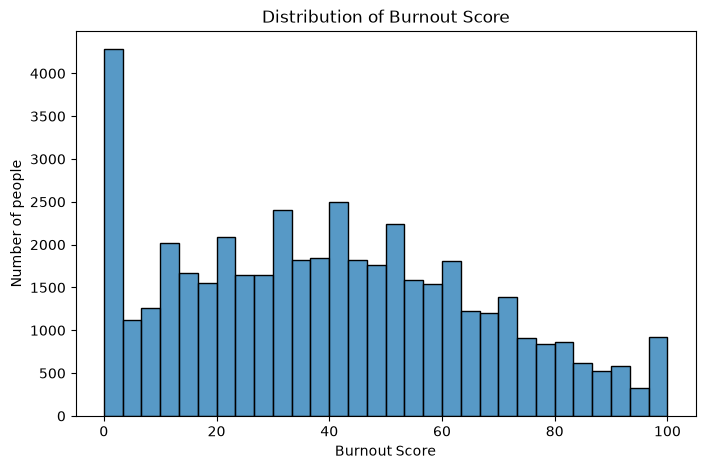

In [93]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Burnout_Score"], bins=30)
plt.title("Distribution of Burnout Score")
plt.xlabel("Burnout Score")
plt.ylabel("Number of people")
plt.show()

### **Numeric predictor variables**

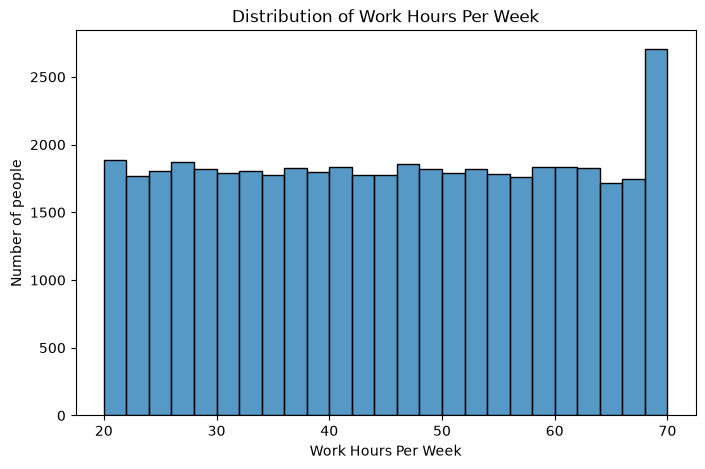

In [94]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Work_Hours_Per_Week"], bins=25)
plt.title("Distribution of Work Hours Per Week")
plt.xlabel("Work Hours Per Week")
plt.ylabel("Number of people")
plt.show()

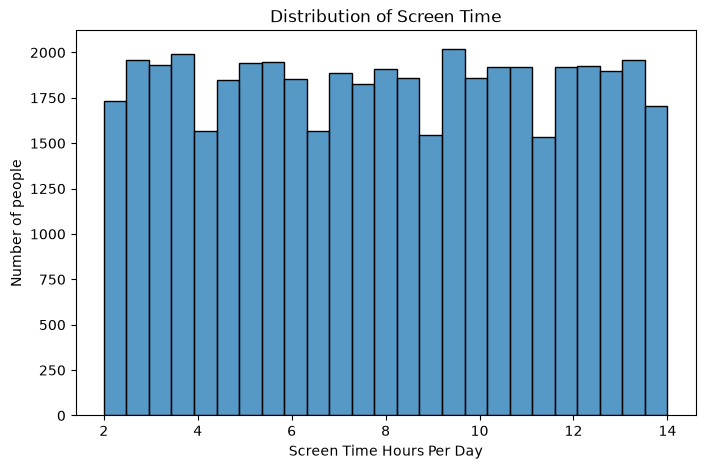

In [95]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Screen_Time_Hours"], bins=25)
plt.title("Distribution of Screen Time")
plt.xlabel("Screen Time Hours Per Day")
plt.ylabel("Number of people")
plt.show()

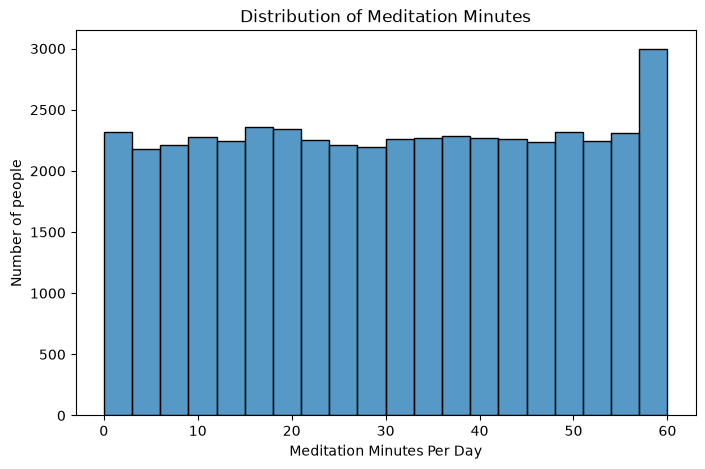

In [96]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Meditation_Minutes"], bins=20)
plt.title("Distribution of Meditation Minutes")
plt.xlabel("Meditation Minutes Per Day")
plt.ylabel("Number of people")
plt.show()

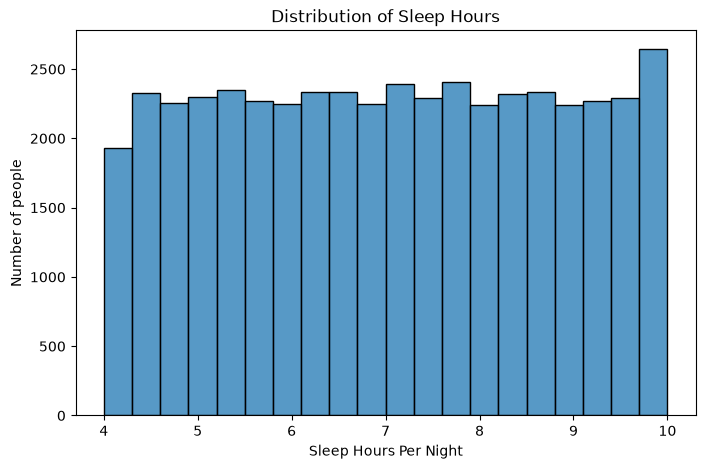

In [97]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Sleep_Hours"], bins=20)
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Number of people")
plt.show()

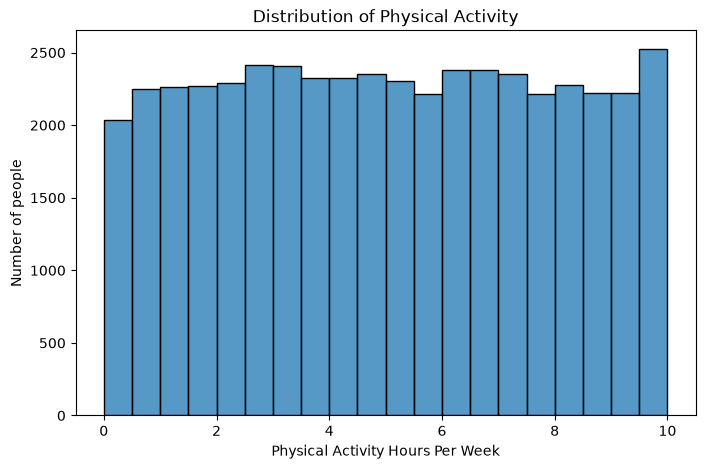

In [98]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Physical_Activity_Hours"], bins=20)
plt.title("Distribution of Physical Activity")
plt.xlabel("Physical Activity Hours Per Week")
plt.ylabel("Number of people")
plt.show()

### **Categorical variables**

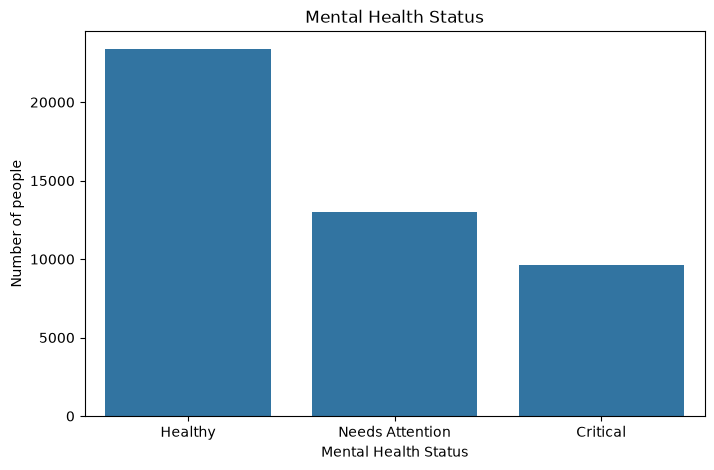

In [99]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data,
    x="Mental_Health_Status",
    order=["Healthy", "Needs Attention", "Critical"],
)
plt.title("Mental Health Status")
plt.xlabel("Mental Health Status")
plt.ylabel("Number of people")
plt.show()

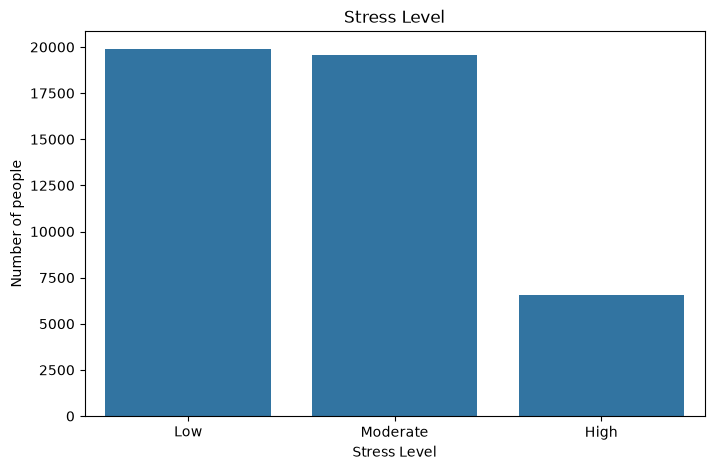

In [100]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Stress_Level", order=["Low", "Moderate", "High"])
plt.title("Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Number of people")
plt.show()

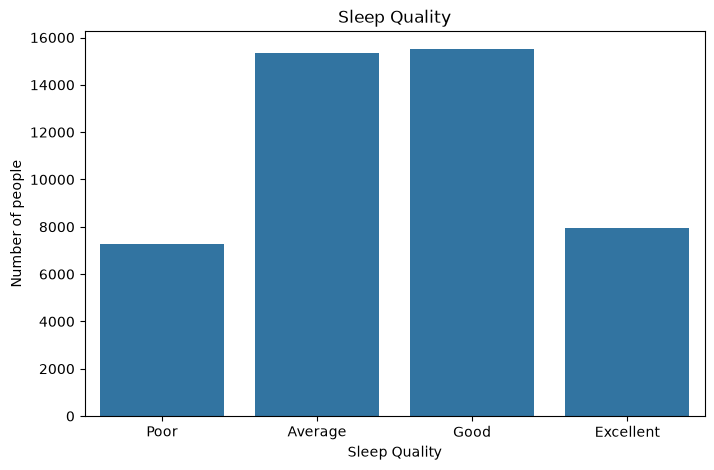

In [101]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data, x="Sleep_Quality", order=["Poor", "Average", "Good", "Excellent"]
)
plt.title("Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Number of people")
plt.show()

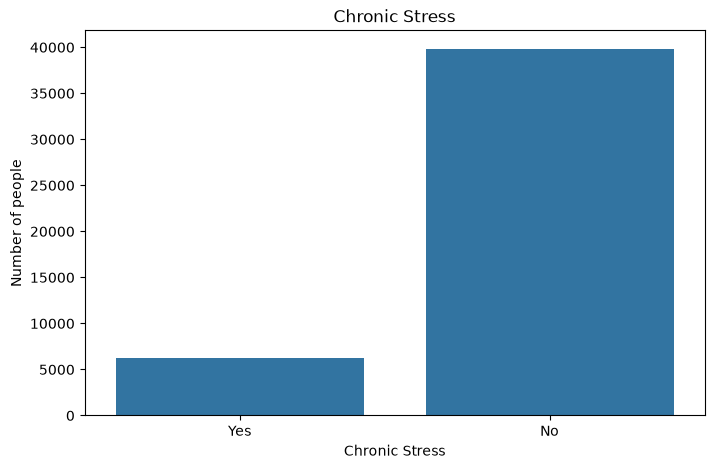

In [102]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Chronic_Stress")
plt.title("Chronic Stress")
plt.xlabel("Chronic Stress")
plt.ylabel("Number of people")
plt.show()

### **Outliers in numeric variables**

Boxplots help us identify unusually low or high values in the numeric variables. An outlier is not automatically an error, so we inspect the values before deciding whether any action is needed.

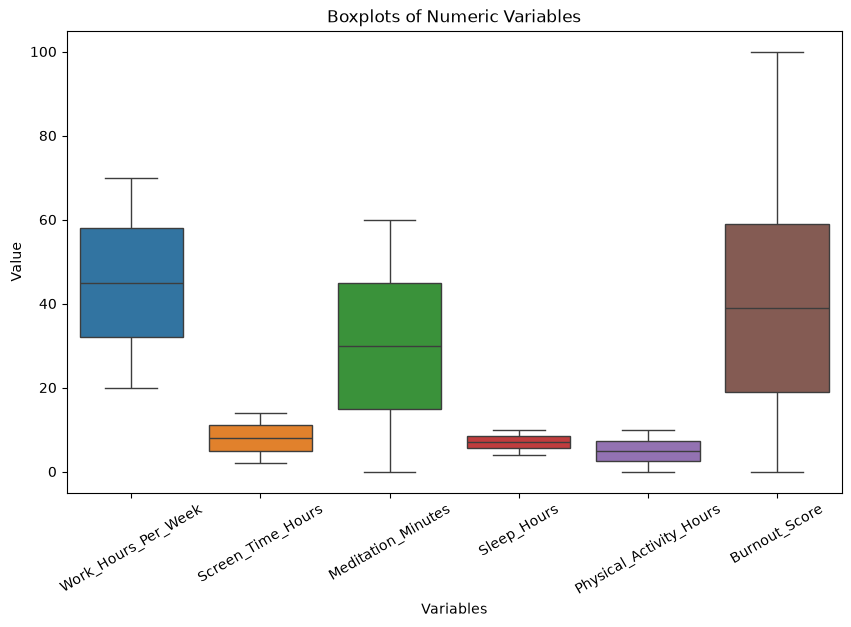

In [103]:
numeric_columns = [
    "Work_Hours_Per_Week",
    "Screen_Time_Hours",
    "Meditation_Minutes",
    "Sleep_Hours",
    "Physical_Activity_Hours",
    "Burnout_Score"
]

plt.figure(figsize=(10, 6))
sns.boxplot(data=data[numeric_columns])
plt.title("Boxplots of Numeric Variables")
plt.xlabel("Variables")
plt.ylabel("Value")
plt.xticks(rotation=30)
plt.show()

The boxplots give us a visual check for possible extreme values. We keep unusual observations unless there is evidence that they are incorrect, because removing valid observations can change the dataset.

## **Correlation analysis**

Before visualizing relationships, we first calculate the correlations between all variables.
For the correlation analysis, the ordinal categories are converted to numbers using the same category order as the project's cleaning step.
This allows us to calculate correlations between the selected variables and organize our visualizations based on actual correlation strength.

In [104]:
encoded_data = data.copy()

stress_encoder = OrdinalEncoder(categories=[["High", "Moderate", "Low"]])
mental_health_encoder = OrdinalEncoder(categories=[["Critical", "Needs Attention", "Healthy"]])
sleep_quality_encoder = OrdinalEncoder(categories=[["Poor", "Average", "Good", "Excellent"]])

encoded_data["Stress_Level"] = stress_encoder.fit_transform(encoded_data[["Stress_Level"]])
encoded_data["Mental_Health_Status"] = mental_health_encoder.fit_transform(encoded_data[["Mental_Health_Status"]])
encoded_data["Sleep_Quality"] = sleep_quality_encoder.fit_transform(encoded_data[["Sleep_Quality"]])

encoded_data = pd.get_dummies(encoded_data, columns=["Chronic_Stress"], dtype=int)

encoded_data.head()

,Mental_Health_Status,Stress_Level,Work_Hours_Per_Week,Screen_Time_Hours,Meditation_Minutes,Sleep_Hours,Sleep_Quality,Physical_Activity_Hours,Burnout_Score,Chronic_Stress_No,Chronic_Stress_Yes
0,0.0,0.0,67,9.1,5.0,4.6,0.0,8.9,82,0,1
1,0.0,1.0,44,12.0,18.0,4.7,0.0,0.8,64,1,0
3,2.0,2.0,25,3.3,55.0,7.1,2.0,7.6,16,1,0
4,2.0,2.0,52,6.5,9.0,9.1,3.0,6.1,26,1,0
5,0.0,1.0,64,6.8,19.0,8.5,2.0,2.0,68,1,0


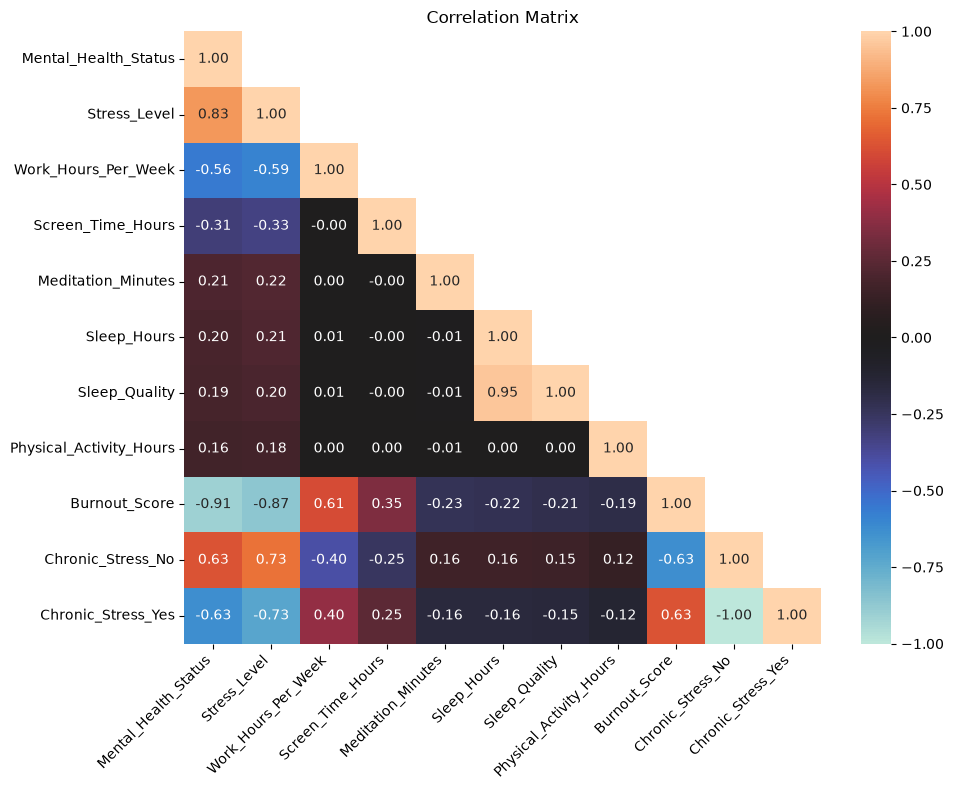

In [105]:
correlation = encoded_data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation, dtype=bool), k=1)
sns.heatmap(correlation, annot=True, fmt=".2f", center=0, vmin=-1, vmax=1, mask=mask)

plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [106]:
burnout_corr = correlation["Burnout_Score"].loc[
    correlation["Burnout_Score"].abs().sort_values(ascending=False).index
]

print("Correlations with Burnout Score (sorted by strength):")
print(burnout_corr)
print("Interpretation:")
print("- Values close to -1 or 1 = strong relationships")
print("- Values close to 0 = weak relationships")

Correlations with Burnout Score (sorted by strength):
Burnout_Score              1.000000
Mental_Health_Status      -0.906472
Stress_Level              -0.866626
Chronic_Stress_Yes         0.628547
Chronic_Stress_No         -0.628547
Work_Hours_Per_Week        0.607543
Screen_Time_Hours          0.350790
Meditation_Minutes        -0.231881
Sleep_Hours               -0.222236
Sleep_Quality             -0.210661
Physical_Activity_Hours   -0.187853
Name: Burnout_Score, dtype: float64
Interpretation:
- Values close to -1 or 1 = strong relationships
- Values close to 0 = weak relationships


## **Relationships with Burnout Score**

Based on the correlations calculated above, we now visualize the relationships organized by strength.
For categories we use boxplots. For numeric variables we use scatterplots.

We organize the variables into groups based on their actual correlation values:
- **A) Strong relationships** (correlation > 0.6)
- **B) Moderate relationships** (correlation 0.3-0.6)
- **C) Weak relationships** (correlation < 0.3)

### **A) Strong Relationships (correlation > 0.6)**

These variables show strong relationships with Burnout Score.

### **Mental Health Status and Burnout Score**

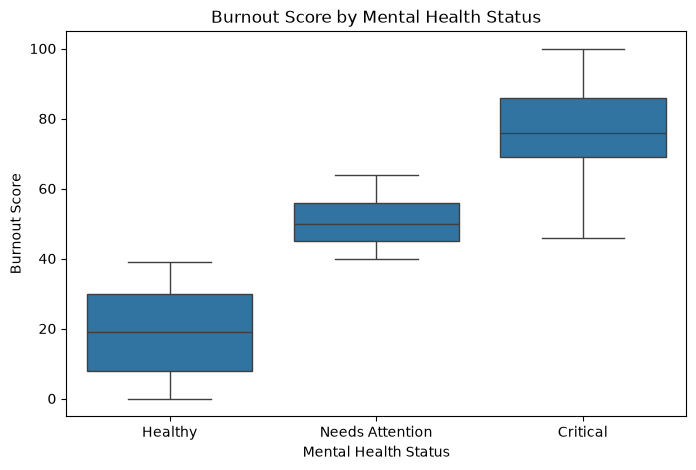

In [107]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Mental_Health_Status", y="Burnout_Score", order=["Healthy", "Needs Attention", "Critical"])
plt.title("Burnout Score by Mental Health Status")
plt.xlabel("Mental Health Status")
plt.ylabel("Burnout Score")
plt.show()

In [108]:
data.groupby("Mental_Health_Status")["Burnout_Score"].mean()

Mental_Health_Status
Critical           77.963753
Healthy            18.669663
Needs Attention    50.734706
Name: Burnout_Score, dtype: float64

### **Stress Level and Burnout Score**

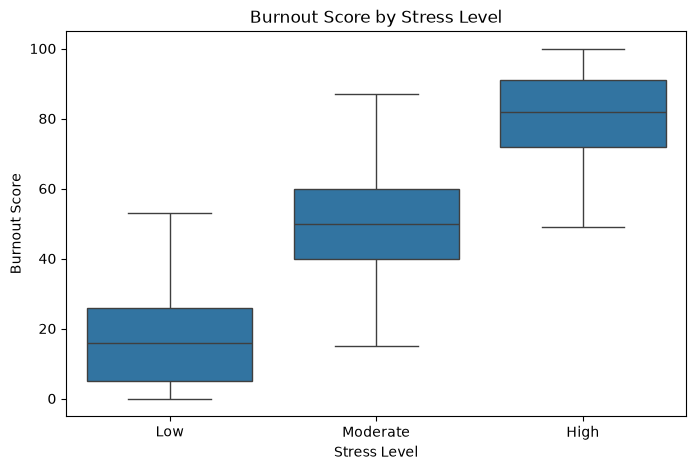

In [109]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Stress_Level", y="Burnout_Score", order=["Low", "Moderate", "High"])
plt.title("Burnout Score by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Burnout Score")
plt.show()

In [110]:
data.groupby("Stress_Level")["Burnout_Score"].mean()

Stress_Level
High        81.207484
Low         16.868401
Moderate    50.039618
Name: Burnout_Score, dtype: float64

### **Chronic Stress and Burnout Score**

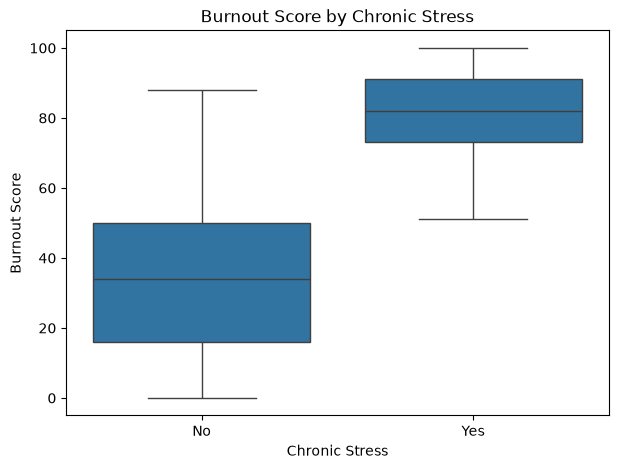

In [111]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="Chronic_Stress", y="Burnout_Score", order=["No", "Yes"])
plt.title("Burnout Score by Chronic Stress")
plt.xlabel("Chronic Stress")
plt.ylabel("Burnout Score")
plt.show()

In [112]:
data.groupby("Chronic_Stress")["Burnout_Score"].mean()

Chronic_Stress
No     33.669546
Yes    81.928088
Name: Burnout_Score, dtype: float64

### **Work Hours and Burnout Score**

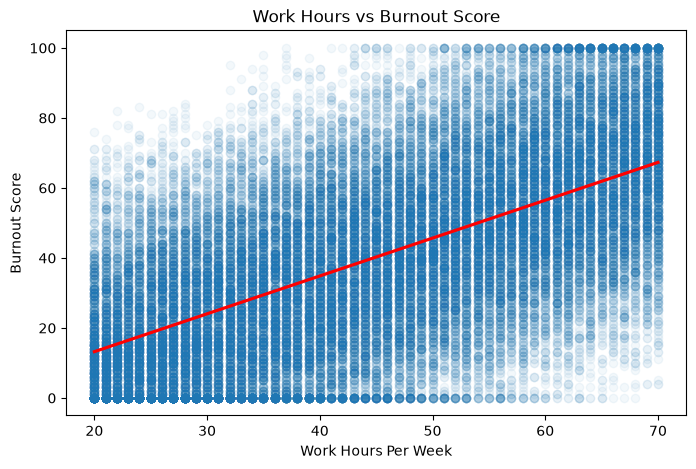

In [113]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=data,
    x="Work_Hours_Per_Week",
    y="Burnout_Score",
    scatter_kws={"alpha": 0.05},
    line_kws={"color": "red"},
)
plt.title("Work Hours vs Burnout Score")
plt.xlabel("Work Hours Per Week")
plt.ylabel("Burnout Score")
plt.show()

### **B) Moderate Relationships (correlation 0.3-0.6)**

These variables show moderate relationships with Burnout Score.

### **Screen Time and Burnout Score**

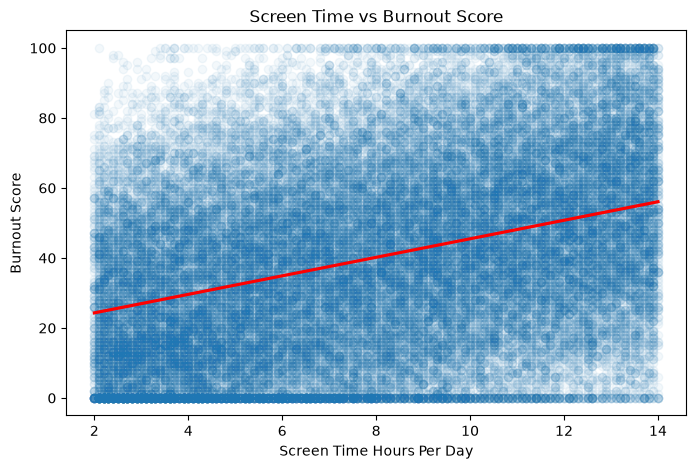

In [114]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=data,
    x="Screen_Time_Hours",
    y="Burnout_Score",
    scatter_kws={"alpha": 0.05},
    line_kws={"color": "red"},
)

plt.title("Screen Time vs Burnout Score")
plt.xlabel("Screen Time Hours Per Day")
plt.ylabel("Burnout Score")
plt.show()

### **C) Weak but Interesting Relationships (correlation < 0.3)**

These variables show weak correlations with Burnout Score, but their visualizations reveal interesting patterns that are worth exploring.

### **Sleep Quality and Burnout Score**

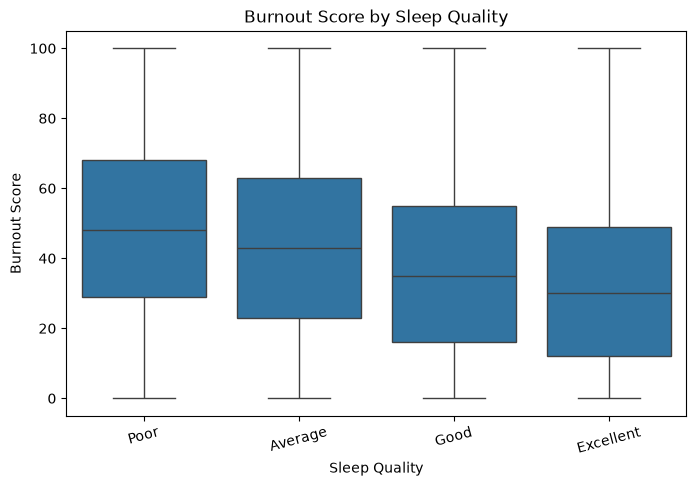

In [115]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=data,
    x="Sleep_Quality",
    y="Burnout_Score",
    order=["Poor", "Average", "Good", "Excellent"],
)
plt.title("Burnout Score by Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Burnout Score")
plt.xticks(rotation=15)
plt.show()

### **Sleep Hours and Burnout Score**

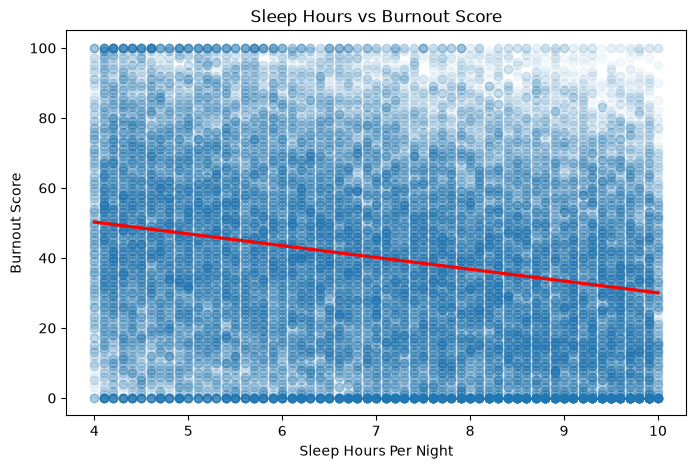

In [116]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=data,
    x="Sleep_Hours",
    y="Burnout_Score",
    scatter_kws={"alpha": 0.05},
    line_kws={"color": "red"},
)

plt.title("Sleep Hours vs Burnout Score")
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Burnout Score")
plt.show()

### **Meditation Minutes and Burnout Score**

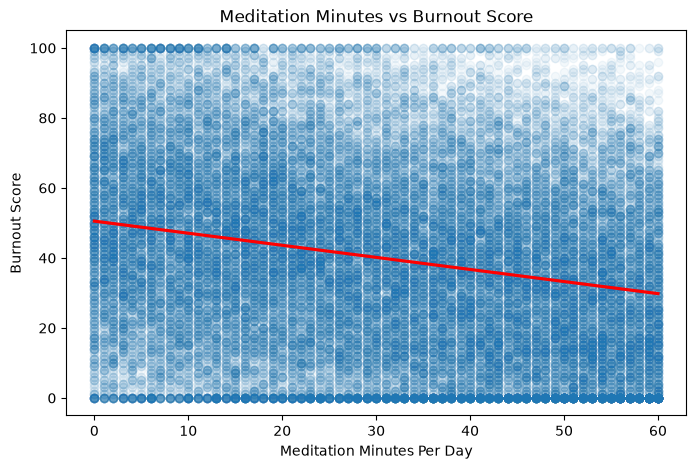

In [117]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=data,
    x="Meditation_Minutes",
    y="Burnout_Score",
    scatter_kws={"alpha": 0.05},
    line_kws={"color": "red"},
)
plt.title("Meditation Minutes vs Burnout Score")
plt.xlabel("Meditation Minutes Per Day")
plt.ylabel("Burnout Score")
plt.show()

### **Physical Activity and Burnout Score**

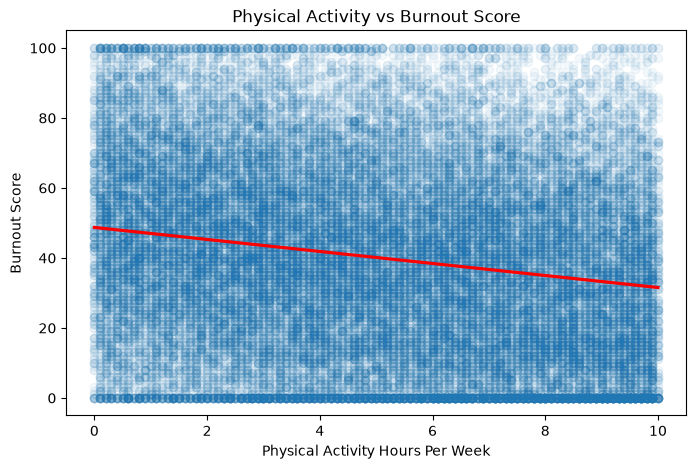

In [118]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=data,
    x="Physical_Activity_Hours",
    y="Burnout_Score",
    scatter_kws={"alpha": 0.05},
    line_kws={"color": "red"},
)
plt.title("Physical Activity vs Burnout Score")
plt.xlabel("Physical Activity Hours Per Week")
plt.ylabel("Burnout Score")
plt.show()


## **Relationships between predictors**

The correlation matrix also shows how the predictor variables relate to each other. This is useful because two predictors can contain similar information.

In [119]:
# Look at correlations between predictors only.
predictor_columns = [
    "Stress_Level",
    "Mental_Health_Status",
    "Chronic_Stress_Yes",
    "Chronic_Stress_No",
    "Work_Hours_Per_Week",
    "Screen_Time_Hours",
    "Meditation_Minutes",
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity_Hours"
]

encoded_data[predictor_columns].corr()

,Stress_Level,Mental_Health_Status,Chronic_Stress_Yes,Chronic_Stress_No,Work_Hours_Per_Week,Screen_Time_Hours,Meditation_Minutes,Sleep_Hours,Sleep_Quality,Physical_Activity_Hours
Stress_Level,1.000000,0.825524,-0.725781,0.725781,-0.589586,-0.331322,0.223399,0.211417,0.200634,0.178889
Mental_Health_Status,0.825524,1.000000,-0.627038,0.627038,-0.555509,-0.308294,0.206480,0.195255,0.186254,0.164860
Chronic_Stress_Yes,-0.725781,-0.627038,1.000000,-1.000000,0.401882,0.250770,-0.161622,-0.159678,-0.151577,-0.124918
Chronic_Stress_No,0.725781,0.627038,-1.000000,1.000000,-0.401882,-0.250770,0.161622,0.159678,0.151577,0.124918
Work_Hours_Per_Week,-0.589586,-0.555509,0.401882,-0.401882,1.000000,-0.001613,0.001724,0.005734,0.005424,0.004694
Screen_Time_Hours,-0.331322,-0.308294,0.250770,-0.250770,-0.001613,1.000000,-0.001195,-0.004428,-0.004185,0.002329
Meditation_Minutes,0.223399,0.206480,-0.161622,0.161622,0.001724,-0.001195,1.000000,-0.007940,-0.010174,-0.007495
Sleep_Hours,0.211417,0.195255,-0.159678,0.159678,0.005734,-0.004428,-0.007940,1.000000,0.954577,0.000997
Sleep_Quality,0.200634,0.186254,-0.151577,0.151577,0.005424,-0.004185,-0.010174,0.954577,1.000000,0.000474
Physical_Activity_Hours,0.178889,0.164860,-0.124918,0.124918,0.004694,0.002329,-0.007495,0.000997,0.000474,1.000000


## **Key findings**

Based on the correlation analysis and visualizations, we can summarize the main patterns found in the selected variables.

**Note:** The correlation values from your data analysis will determine which variables fall into each category (Strong/Moderate/Weak). The visualizations above show the actual relationships.

**Key observations:**
- Variables with correlations closer to -1 or 1 show stronger relationships with Burnout Score
- Even variables with weak correlations can show interesting patterns in visualizations
- Missing values were removed before the variables were used for modelling, following the same approach as the project's cleaning script

**Important note:** A correlation or pattern in the EDA shows an association. It does not by itself prove that one variable causes another.